# Single Step Predictions

The following notebook creates and evalutes models a single step into the future. Models are trained on 24 hours of Soil Moisture Data, and then make a prediction for one hour of soil moisture 24 hours in the future.

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
# 0 = all messages are logged (default behavior)
# 1 = INFO messages are not printed
# 2 = INFO and WARNING messages are not printed
# 3 = INFO, WARNING, and ERROR messages are not printed

import datetime

import IPython
import IPython.display
import matplotlib as mpl
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
#from google.colab import drive
#drive.mount('/content/gdrive')

mpl.rcParams['figure.figsize'] = (8, 6)
mpl.rcParams['axes.grid'] = False

import warnings
# https://stackoverflow.com/questions/15777951/how-to-suppress-pandas-future-warning
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)

tf.get_logger().setLevel('ERROR')
tf.autograph.set_verbosity(0)

import logging
tf.get_logger().setLevel(logging.ERROR)

# https://stackoverflow.com/questions/65697623/tensorflow-warning-found-untraced-functions-such-as-lstm-cell-6-layer-call-and
import absl.logging
absl.logging.set_verbosity(absl.logging.ERROR)

In [2]:
# Mounting Drive
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


### Data Cleansing, Normalization and Split

The following section reads in the data, vectorizes wind and time, and creates a treaining, validation and testing data frame for each station using only the overlapping time indexes.

In [3]:
%cd /content/drive/My Drive/TX_DATA/BestData

/content/drive/My Drive/TX_DATA/BestData


In [4]:
#Read In Data
dfs = {}
for index in range(0, 6):
  df = pd.read_csv('Station' + str(index + 1) + '-Simulated-cleaned-merged-data.csv', sep=",", parse_dates=["Date"], index_col="Date")
  dfs['Station' + str(index + 1)] = df

In [5]:
# Vectorize wind
for station, df in dfs.items():
  wv = df.pop('Windspeed')
  wd_rad = df.pop('Winddirection')*np.pi / 180
  df['Wx'] = wv*np.cos(wd_rad)
  df['Wy'] = wv*np.sin(wd_rad)
  dfs[station] = df

In [6]:
# Remove periodicity in time data (remove daily and yearly periodicity)
day = 24*60*60
year = (365.2425)*day

for station, df in dfs.items() :
  timestamp_s = (df.index).map(pd.Timestamp.timestamp)
  df['Day sin'] = np.sin(timestamp_s * (2 * np.pi / day))
  df['Day cos'] = np.cos(timestamp_s * (2 * np.pi / day))
  df['Year sin'] = np.sin(timestamp_s * (2 * np.pi / year))
  df['Year cos'] = np.cos(timestamp_s * (2 * np.pi / year))
  dfs[station] = df

In [7]:
#Pop longitude and lattitude, normalize them seperately
for key in dfs.keys():
  dfs[key] = dfs[key][["SWC_5", "SWC_10", "SWC_20","SWC_50"]]



In [8]:
#Use only overlapping indexes
index_union = pd.Index([])
for station, df in dfs.items():
  index_union = index_union.union(df.index)
index_int = index_union
for station, df in dfs.items():
  index_int = index_int.intersection(df.index)

In [9]:
split_dfs = {}
n = len(index_int)
column_indices = {name: i for i, name in enumerate(df.columns)}
for station, df in dfs.items():
  df = df.loc[index_int]
  split_dfs[station] = {
      "train_df": df[0:int(n*0.7)],
      "val_df": df[int(n*0.7):int(n*0.9)],
      "test_df": df[int(n*0.9):]
  }

### Windowing

The section below define functions for creating windows for time series analysis as well as functions to plot them.

In [10]:
class WindowGenerator():
  def __init__(self, input_width, label_width, shift,
               train_df, val_df, test_df,
               label_columns=None):
    # Store the raw data.
    self.train_df = train_df
    self.val_df = val_df
    self.test_df = test_df

    # Work out the label column indices.
    self.label_columns = label_columns
    if label_columns is not None:
      self.label_columns_indices = {name: i for i, name in
                                    enumerate(label_columns)}
    self.column_indices = {name: i for i, name in
                           enumerate(train_df.columns)}

    # Work out the window parameters.
    self.input_width = input_width
    self.label_width = label_width
    self.shift = shift

    self.total_window_size = input_width + shift

    self.input_slice = slice(0, input_width)
    self.input_indices = np.arange(self.total_window_size)[self.input_slice]

    self.label_start = self.total_window_size - self.label_width
    self.labels_slice = slice(self.label_start, None)
    self.label_indices = np.arange(self.total_window_size)[self.labels_slice]

  def __repr__(self):
    return '\n'.join([
        f'Total window size: {self.total_window_size}',
        f'Input indices: {self.input_indices}',
        f'Label indices: {self.label_indices}',
        f'Label column name(s): {self.label_columns}'])



In [11]:
def split_window(self, features):
  inputs = features[:, self.input_slice, :]
  labels = features[:, self.labels_slice, :]
  if self.label_columns is not None:
    labels = tf.stack(
        [labels[:, :, self.column_indices[name]] for name in self.label_columns],
        axis=-1)

  # Slicing doesn't preserve static shape information, so set the shapes
  # manually. This way the `tf.data.Datasets` are easier to inspect.
  inputs.set_shape([None, self.input_width, None])
  labels.set_shape([None, self.label_width, None])

  return inputs, labels

WindowGenerator.split_window = split_window

In [12]:
def plot(self, model=None, plot_col='SWC_5', max_subplots=3):
  inputs, labels = self.example
  plt.figure(figsize=(12, 8))
  plot_col_index = self.column_indices[plot_col]
  max_n = min(max_subplots, len(inputs))
  for n in range(max_n):
    plt.subplot(max_n, 1, n+1)
    plt.ylabel(f'{plot_col} [normed]')
    plt.plot(self.input_indices, inputs[n, :, plot_col_index],
             label='Inputs', marker='.', zorder=-10)

    if self.label_columns:
      label_col_index = self.label_columns_indices.get(plot_col, None)
    else:
      label_col_index = plot_col_index

    if label_col_index is None:
      continue

    plt.scatter(self.label_indices, labels[n, :, label_col_index],
                edgecolors='k', label='Labels', c='#2ca02c', s=64)
    if model is not None:
      predictions = model(inputs)
      plt.scatter(self.label_indices, predictions[n, :, label_col_index],
                  marker='X', edgecolors='k', label='Predictions',
                  c='#ff7f0e', s=64)

    if n == 0:
      plt.legend()

  plt.xlabel('Date')

WindowGenerator.plot = plot

In [13]:
def make_dataset(self, data):
  data = np.array(data, dtype=np.float32)
  ds = tf.keras.utils.timeseries_dataset_from_array(
      data=data,
      targets=None,
      sequence_length=self.total_window_size,
      sequence_stride=1,
      shuffle=True,
      batch_size=32,)

  ds = ds.map(self.split_window)

  return ds

WindowGenerator.make_dataset = make_dataset

In [14]:
@property
def train(self):
  return self.make_dataset(self.train_df)

@property
def val(self):
  return self.make_dataset(self.val_df)

@property
def test(self):
  return self.make_dataset(self.test_df)

@property
def example(self):
  """Get and cache an example batch of `inputs, labels` for plotting."""
  result = getattr(self, '_example', None)
  if result is None:
    # No example batch was found, so get one from the `.train` dataset
    result = next(iter(self.train))
    # And cache it for next time
    self._example = result
  return result

WindowGenerator.train = train
WindowGenerator.val = val
WindowGenerator.test = test
WindowGenerator.example = example

### Modeling

Multi-Step Dense, CNN, RNN and AR RNN models are testing in the same freamwork.

In [15]:
val_performance = {}
performance = {}

In [16]:
#function for quick compile and fit
from keras.callbacks import ModelCheckpoint
MAX_EPOCHS = 3

def compile_and_fit(model, folder, window, patience=3):
  early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                                    patience=patience,
                                                    mode='min')
  cp1 = ModelCheckpoint(folder, save_best_only=True)

  model.compile(loss=tf.keras.losses.MeanSquaredError(),
                optimizer=tf.keras.optimizers.Adam(),
                metrics=[tf.keras.metrics.MeanAbsoluteError()])

  history = model.fit(window.train, epochs=MAX_EPOCHS,
                      validation_data=window.val,
                      callbacks=[early_stopping])
  return history

In [17]:
df_1 = split_dfs["Station1"]

train = df_1["train_df"]
val = df_1["val_df"]
test = df_1["test_df"]

train

,SWC_5,SWC_10,SWC_20,SWC_50
2015-01-01 00:00:00,0.139,0.178,0.148,0.152
2015-01-01 01:00:00,0.139,0.178,0.148,0.152
2015-01-01 02:00:00,0.139,0.178,0.148,0.152
2015-01-01 03:00:00,0.139,0.178,0.148,0.152
2015-01-01 04:00:00,0.139,0.178,0.148,0.152
...,...,...,...,...
2019-07-18 20:00:00,0.098,0.109,0.106,0.110
2019-07-18 21:00:00,0.097,0.108,0.106,0.110
2019-07-18 22:00:00,0.097,0.108,0.105,0.110
2019-07-18 23:00:00,0.096,0.107,0.105,0.110


In [18]:
window = WindowGenerator(
    input_width=24, label_width = 1, shift=24,
    label_columns=['SWC_5'], train_df = train,
    val_df = val, test_df = test)

window

Total window size: 48
Input indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
Label indices: [47]
Label column name(s): ['SWC_5']

In [19]:
multi_step_dense = tf.keras.Sequential([
    # Shape: (time, features) => (time*features)
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(units=32, activation='relu'),
    tf.keras.layers.Dense(units=32, activation='relu'),
    tf.keras.layers.Dense(units=1),
    # Add back the time dimension.
    # Shape: (outputs) => (1, outputs)
    tf.keras.layers.Reshape([1, -1]),
])

In [ ]:
MSD_history = compile_and_fit(multi_step_dense,"MSD", window)

IPython.display.clear_output()
val_performance['Multi step dense'] = multi_step_dense.evaluate(window.val)
performance['Multi step dense'] = multi_step_dense.evaluate(window.test, verbose=0)

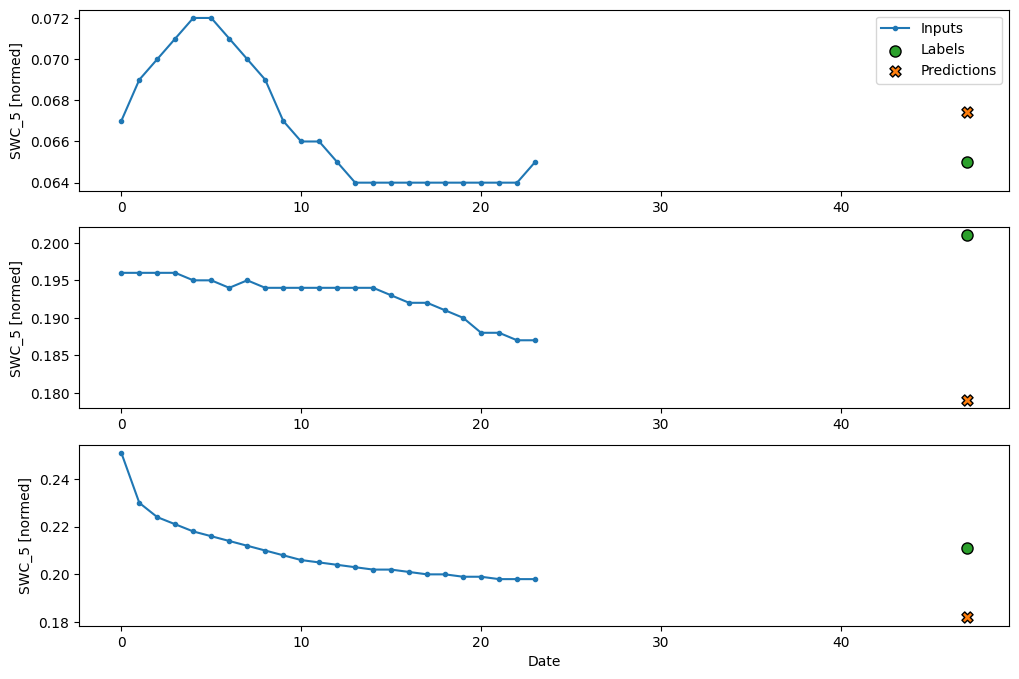

In [21]:
window.plot(multi_step_dense)


In [22]:
conv_model = tf.keras.Sequential([
    tf.keras.layers.Conv1D(filters=32,
                           kernel_size=(24,),
                           activation='relu'),
    tf.keras.layers.Dense(units=32, activation='relu'),
    tf.keras.layers.Dense(units=1),
])

In [23]:
CNN_history = compile_and_fit(conv_model,"CNN", window)

IPython.display.clear_output()
val_performance['Conv'] = conv_model.evaluate(window.val)
performance['Conv'] = conv_model.evaluate(window.test, verbose=0)

343/343 [==============================] - 2s 4ms/step - loss: 6.4173e-04 - mean_absolute_error: 0.0132


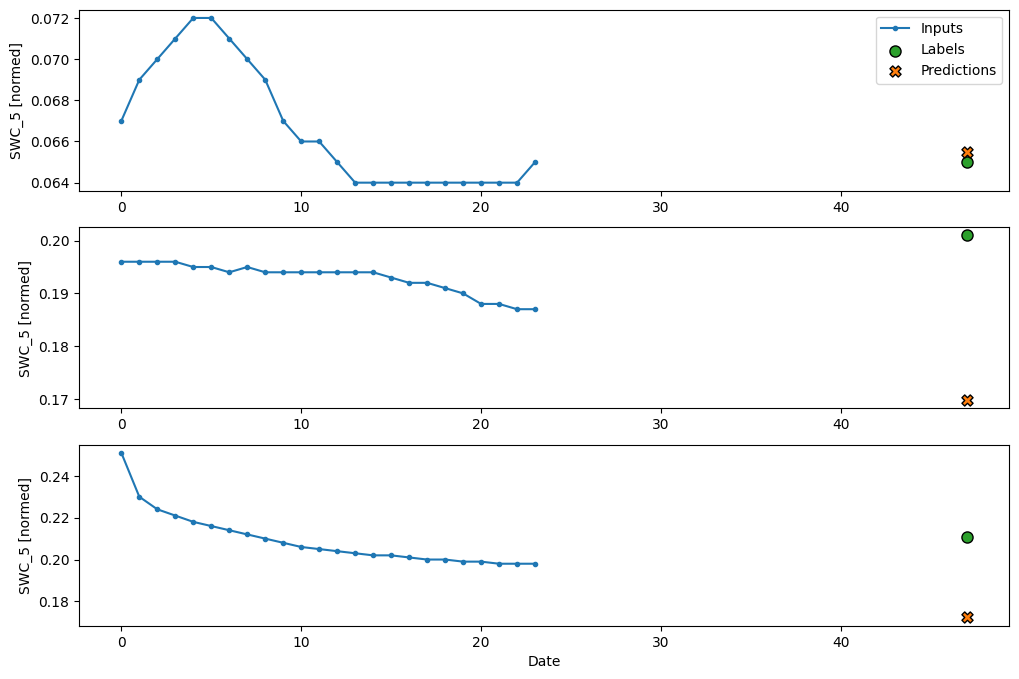

In [24]:
window.plot(conv_model)

In [25]:
lstm_window = WindowGenerator(
    input_width=24, label_width = 24, shift=24,
    label_columns=['SWC_5'], train_df = train,
    val_df = val, test_df = test)


In [26]:
lstm_model = tf.keras.models.Sequential([
    # Shape [batch, time, features] => [batch, time, lstm_units]
    tf.keras.layers.LSTM(32, return_sequences=True),
    # Shape => [batch, time, features]
    tf.keras.layers.Dense(units=1)
])

In [27]:
lstm_history = compile_and_fit(lstm_model,"lstm", window)

IPython.display.clear_output()
val_performance['LSTM'] = lstm_model.evaluate(window.val)
performance['LSTM'] = lstm_model.evaluate(window.test, verbose=0)

343/343 [==============================] - 3s 8ms/step - loss: 7.4233e-04 - mean_absolute_error: 0.0159


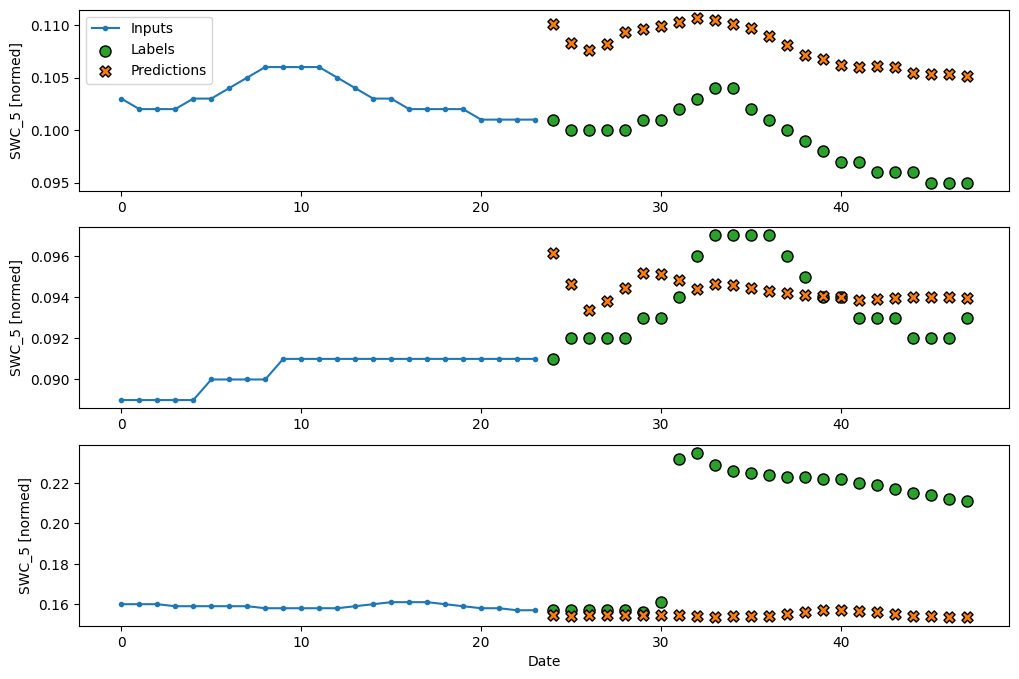

In [28]:
lstm_window.plot(lstm_model)

Note: I couldn't get the lstm window to plot on the normal window used for all the others. It's still trained the same way.

In [29]:
class FeedBack(tf.keras.Model):
  def __init__(self, units, out_steps):
    super().__init__()
    self.out_steps = out_steps
    self.units = units
    self.lstm_cell = tf.keras.layers.LSTMCell(units)
    # Also wrap the LSTMCell in an RNN to simplify the `warmup` method.
    self.lstm_rnn = tf.keras.layers.RNN(self.lstm_cell, return_state=True)
    self.dense = tf.keras.layers.Dense(1)

In [30]:
feedback_model = FeedBack(units=32, out_steps=1)

In [31]:
def warmup(self, inputs):
  # inputs.shape => (batch, time, features)
  # x.shape => (batch, lstm_units)
  x, *state = self.lstm_rnn(inputs)

  # predictions.shape => (batch, features)
  prediction = self.dense(x)
  return prediction, state

FeedBack.warmup = warmup

In [32]:
prediction, state = feedback_model.warmup(window.example[0])
print(prediction.shape)

(32, 1)


In [33]:
#Original
def call(self, inputs, training=None):
  # Use a TensorArray to capture dynamically unrolled outputs.
  predictions = []
  # Initialize the LSTM state.
  prediction, state = self.warmup(inputs)

  # Insert the first prediction.
  predictions.append(prediction)

  # Run the rest of the prediction steps.
  for n in range(1, self.out_steps):
    # Use the last prediction as input.
    x = prediction
    # Execute one lstm step.
    x, state = self.lstm_cell(x, states=state,
                              training=training)
    # Convert the lstm output to a prediction.
    prediction = self.dense(x)
    # Add the prediction to the output.
    predictions.append(prediction)

  # predictions.shape => (time, batch, features)
  predictions = tf.stack(predictions)
  # predictions.shape => (batch, time, features)
  predictions = tf.transpose(predictions, [1, 0, 2])
  return predictions

FeedBack.call = call

In [34]:
print('Output shape (batch, time, features): ', feedback_model(window.example[0]).shape)

Output shape (batch, time, features):  (32, 1, 1)


In [35]:
AR_history = compile_and_fit(feedback_model,"AR", window)

IPython.display.clear_output()

val_performance['AR LSTM'] = feedback_model.evaluate(window.val)
performance['AR LSTM'] = feedback_model.evaluate(window.test, verbose=0)


343/343 [==============================] - 3s 8ms/step - loss: 5.4185e-04 - mean_absolute_error: 0.0120


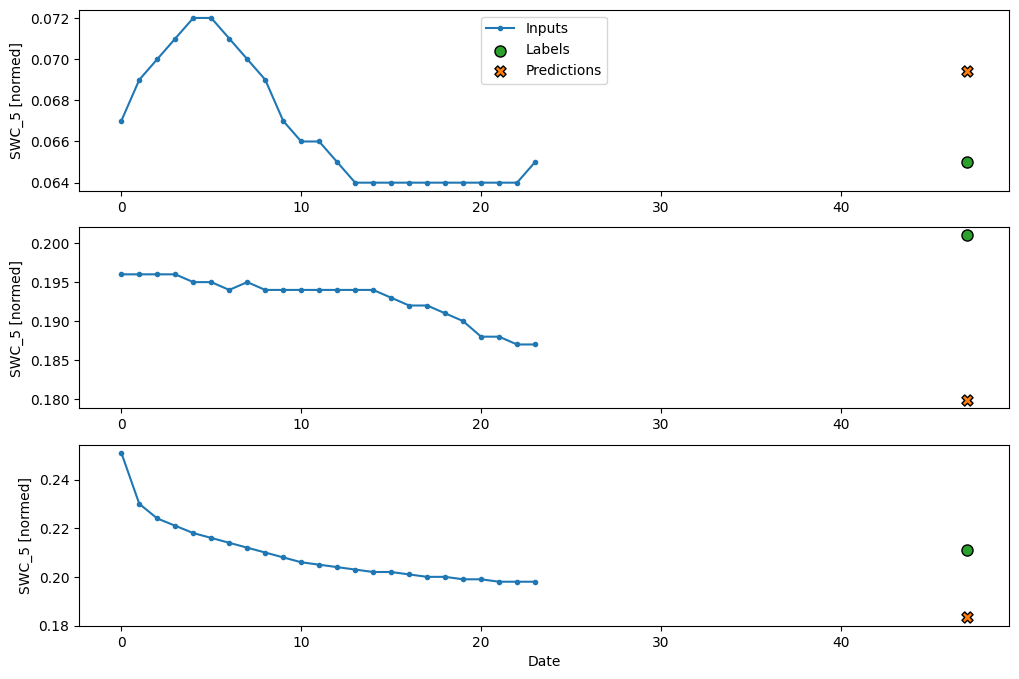

In [36]:
window.plot(feedback_model)

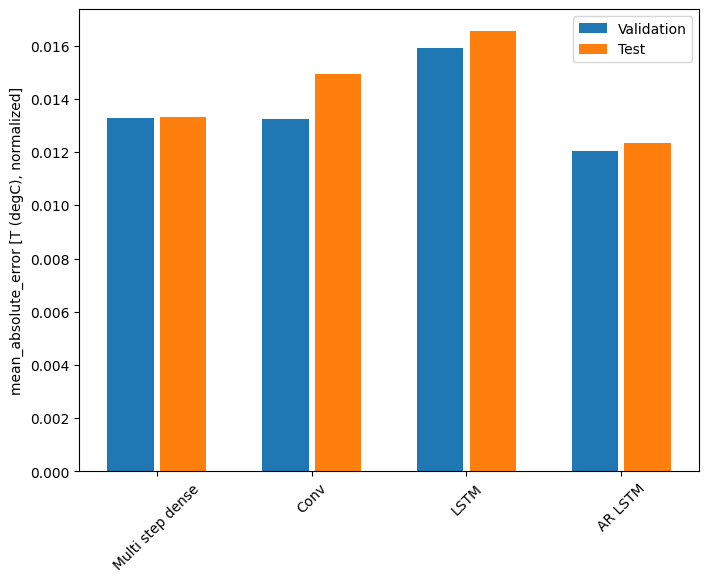

In [37]:
x = np.arange(len(performance))
width = 0.3
metric_name = 'mean_absolute_error'
metric_index = lstm_model.metrics_names.index('mean_absolute_error')
val_mae = [v[metric_index] for v in val_performance.values()]
test_mae = [v[metric_index] for v in performance.values()]

plt.ylabel('mean_absolute_error [T (degC), normalized]')
plt.bar(x - 0.17, val_mae, width, label='Validation')
plt.bar(x + 0.17, test_mae, width, label='Test')
plt.xticks(ticks=x, labels=performance.keys(),
           rotation=45)
_ = plt.legend()